# Titanic — the classic first classification (real data)

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 1 — The history of AI, and how we got to today  
**Rows:** 1,309  ·  **Source file:** `titanic.csv`

All 1,309 passengers of the 1912 voyage: class, name, sex, age, family aboard, fare, port — and survival. The dataset Lecture 2 runs on, and the standard first classification problem in machine learning.

The Lecture 2 dataset, on your own machine: predict survival from what was known at boarding. The point is not the boat — it is learning to read a model: baselines, coefficients as odds, the confusion matrix, and interactions (sex × class) that averages hide.

---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/titanic.csv"
LOCAL = "titanic.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (1309, 9)


,pclass,survived,name,sex,age,sibsp,parch,fare,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,211.3375,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,151.5500,S
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,151.5500,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,151.5500,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,151.5500,S


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
pclass        int64
survived      int64
name            str
sex             str
age         float64
sibsp         int64
parch         int64
fare        float64
embarked        str

Missing values:
age         263
fare          1
embarked      2


---
## Problem 1 · Easy — describe

Compute the survival rate overall, by sex, and by class. Then the lecture's sex × class table — women 1st/2nd/3rd, men, children under 16. Which cell surprises you most?

*Try it yourself first. The worked solution is below.*

In [3]:
print("Overall survival: %.0f%%  (%d of %d)" % (100*df.survived.mean(), df.survived.sum(), len(df)))
print("\nBy sex (%):");   print((df.groupby("sex")["survived"].mean()*100).round(0).to_string())
print("\nBy class (%):"); print((df.groupby("pclass")["survived"].mean()*100).round(0).to_string())
piv = df.pivot_table(index="sex", columns="pclass", values="survived", aggfunc="mean").mul(100).round(0)
print("\nSex x class (%):"); print(piv.to_string())
ch = df[df.age < 16]
print("\nChildren under 16, by class (%):")
print((ch.groupby("pclass")["survived"].mean()*100).round(0).to_string())
print("\nThe surprise: a child in SECOND class (96%) fared better than in first (88%),")
print("and only 41% of third-class children survived. The averages hide the interaction.")

Overall survival: 38%  (500 of 1309)

By sex (%):
sex
female    73.0
male      19.0

By class (%):
pclass
1    62.0
2    43.0
3    26.0

Sex x class (%):
pclass     1     2     3
sex                     
female  97.0  89.0  49.0
male    34.0  15.0  15.0

Children under 16, by class (%):
pclass
1    88.0
2    96.0
3    41.0

The surprise: a child in SECOND class (96%) fared better than in first (88%),
and only 41% of third-class children survived. The averages hide the interaction.


---
## Problem 2 · Intermediate — build

Beat the baselines: "everyone dies" scores 62%, "women live, men die" scores 78%. Train a logistic regression and report test accuracy AND the confusion matrix — how many survivors does it miss?

*Try it yourself first. The worked solution is below.*

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

print("Baseline 1 - everyone dies:        %.0f%%" % (100*(1-df.survived.mean())))
rule = ((df.sex=="female") == (df.survived==1)).mean()
print("Baseline 2 - women live, men die:  %.0f%%" % (100*rule))

d = df.copy()
d["female"] = (d.sex=="female").astype(int)
d["age"]  = d.age.fillna(d.age.median())
d["fare"] = d.fare.fillna(d.fare.median())
X = pd.get_dummies(d[["pclass","female","age","sibsp","parch","fare","embarked"]],
                   columns=["embarked"], dummy_na=True)
y = d.survived
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
m = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
pred = m.predict(Xte)
print("\nLogistic regression, test accuracy: %.0f%%" % (100*accuracy_score(yte, pred)))
tn, fp, fn, tp = confusion_matrix(yte, pred).ravel()
print("\nConfusion matrix (test set):")
print(pd.DataFrame([[tn, fp],[fn, tp]],
      index=["actually died","actually survived"],
      columns=["predicted died","predicted survived"]).to_string())
print("\nIt misses %d of %d true survivors (%.0f%%)." % (fn, fn+tp, 100*fn/(fn+tp)))
print("Accuracy hides the shape of the error - the matrix shows it.")

Baseline 1 - everyone dies:        62%
Baseline 2 - women live, men die:  78%

Logistic regression, test accuracy: 80%

Confusion matrix (test set):
                   predicted died  predicted survived
actually died                 174                  29
actually survived              36                  89

It misses 36 of 125 true survivors (29%).
Accuracy hides the shape of the error - the matrix shows it.


---
## Problem 3 · Advanced — judge

Interpret, don't just score: turn the coefficients into odds multipliers, add a sex × class interaction, and judge what would and would not transfer to a modern setting.

*Try it yourself first. The worked solution is below.*

In [5]:
import numpy as np
odds = pd.Series(np.exp(m.coef_[0]), index=X.columns).sort_values(ascending=False)
print("Odds multipliers (logistic multiplies odds; linear adds units):")
print(odds.round(3).to_string())
print("\nRead it: female x%.1f the odds of survival; each class step DOWN x%.2f;" % (odds["female"], odds["pclass"]))
print("each extra year of age x%.3f - small per year, decisive over decades." % odds["age"])

X2 = X.copy(); X2["female_x_class"] = X2.female * X2.pclass
X2tr, X2te = X2.loc[Xtr.index], X2.loc[Xte.index]
m2 = LogisticRegression(max_iter=2000).fit(X2tr, ytr)
print("\nWith the sex x class interaction: %.0f%% (was %.0f%%)"
      % (100*accuracy_score(yte, m2.predict(X2te)), 100*accuracy_score(yte, pred)))
print("The interaction term lets one model say what the pivot table said:")
print("being a woman was worth more in first class than in third.")
print("\nWhat transfers to a modern evacuation model: the METHOD - baselines,")
print("odds, the confusion matrix. What does not: every coefficient. 1912 class")
print("structure, lifeboat rules and social norms are baked into each number.")

Odds multipliers (logistic multiplies odds; linear adds units):
female          11.570
embarked_C       1.686
parch            1.003
fare             1.002
embarked_nan     1.000
age              0.965
embarked_S       0.844
embarked_Q       0.763
sibsp            0.716
pclass           0.429

Read it: female x11.6 the odds of survival; each class step DOWN x0.43;
each extra year of age x0.965 - small per year, decisive over decades.

With the sex x class interaction: 83% (was 80%)
The interaction term lets one model say what the pivot table said:
being a woman was worth more in first class than in third.

What transfers to a modern evacuation model: the METHOD - baselines,
odds, the confusion matrix. What does not: every coefficient. 1912 class
structure, lifeboat rules and social norms are baked into each number.


---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


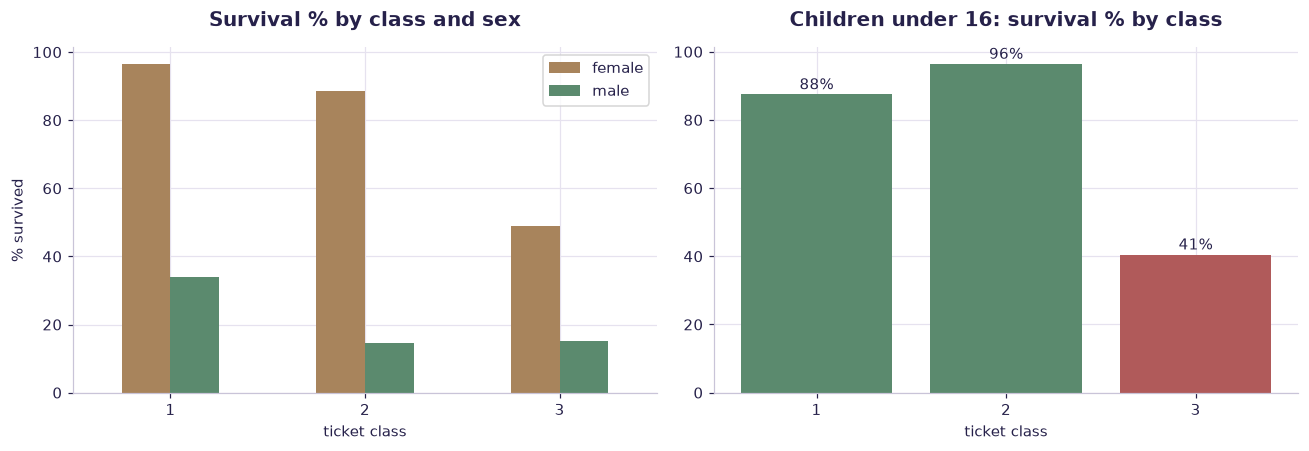

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
piv = df.pivot_table(index="pclass", columns="sex", values="survived", aggfunc="mean").mul(100)
piv.plot(kind="bar", ax=ax[0], color=[BUILDER, CORE], rot=0)
ax[0].set_title("Survival % by class and sex"); ax[0].set_xlabel("ticket class"); ax[0].set_ylabel("% survived")
ax[0].legend(title=None)
ch = df[df.age < 16].groupby("pclass")["survived"].mean().mul(100)
ax[1].bar(ch.index.astype(str), ch.values, color=[CORE if v > 60 else DANGER for v in ch.values])
ax[1].set_title("Children under 16: survival % by class"); ax[1].set_xlabel("ticket class")
for x, v in zip(ch.index.astype(str), ch.values): ax[1].text(x, v + 1.5, "%.0f%%" % v, ha="center", fontsize=10)
plt.tight_layout(); plt.show()

---
## More visuals — the questions a room asks next

The summary above answers the three problems. This answers what gets asked
immediately afterwards: how each variable is actually distributed, what moves
with what, where the outcome concentrates, and how much of the total sits in how
few rows. The same six views appear in every dataset's notebook, so they can be
compared rather than relearned.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


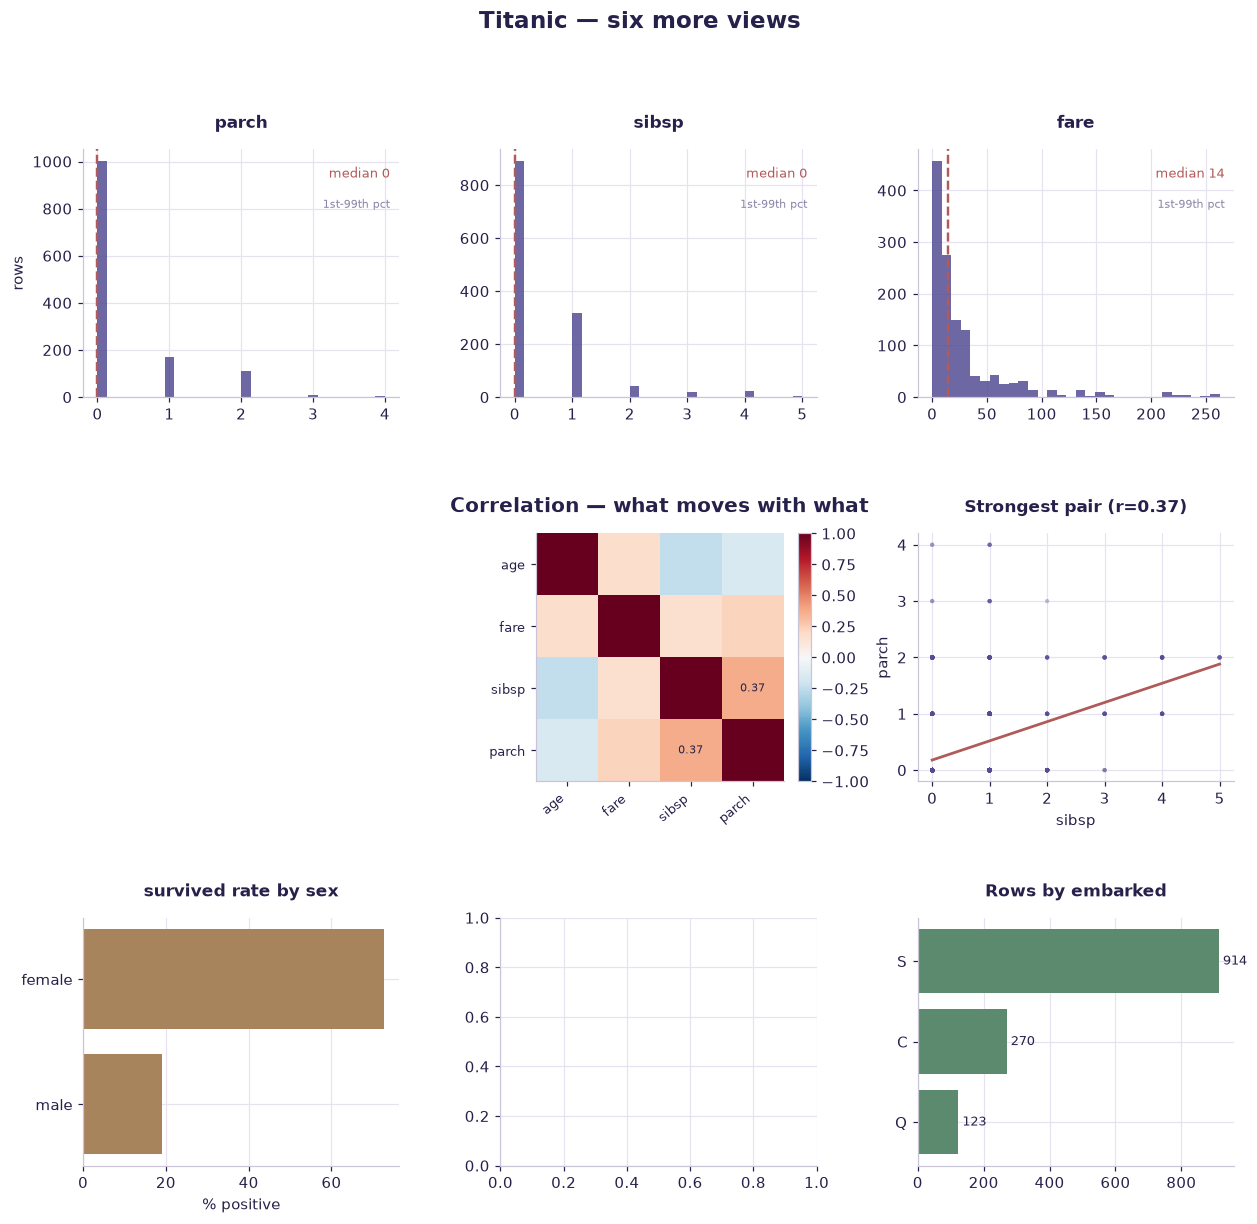

In [7]:
def deep_visuals(df, target=None, cats=None, nums=None, title=""):
    '''Six more views of the same table.

    The single summary figure answers the three problems. This answers the
    questions a room asks next: how is each variable actually distributed, what
    moves with what, where does the target concentrate, and how much of the
    total sits in how few rows. Written once and configured per dataset, so
    every notebook shows the same six views and a learner can compare across
    datasets instead of relearning a new chart each time.
    '''
    import numpy as np, pandas as pd, matplotlib.pyplot as plt

    nums = nums or [c for c in df.select_dtypes("number").columns][:8]
    cats = cats or [c for c in df.select_dtypes("object").columns
                    if 1 < df[c].nunique() <= 12][:3]
    # A column named as numeric may still be stored as text (a rating written
    # "4 / 5", a salary with a thousands separator). Coerce, then keep only what
    # actually became numbers — otherwise the correlation step dies on a string.
    df = df.copy()
    keep = []
    for c in nums:
        if c not in df.columns:
            continue
        if not pd.api.types.is_numeric_dtype(df[c]):
            conv = pd.to_numeric(
                df[c].astype(str).str.replace(r"[^\d.\-]", "", regex=True).replace("", np.nan),
                errors="coerce")
            if conv.notna().mean() < .6:
                continue
            df[c] = conv
        keep.append(c)
    nums = keep
    cats = [c for c in cats if c in df.columns]

    fig = plt.figure(figsize=(13.5, 12))
    gs  = fig.add_gridspec(3, 3, hspace=.55, wspace=.32)
    if title:
        fig.suptitle(title, fontsize=15, color=INK, y=.985, fontweight="600")

    # 1 — distribution of the three most variable numeric columns
    show = sorted(nums, key=lambda c: df[c].std(ddof=0) / (abs(df[c].mean()) + 1e-9),
                  reverse=True)[:3]
    for i, c in enumerate(show):
        ax = fig.add_subplot(gs[0, i])
        v = df[c].dropna()
        # Real business data is long-tailed: one 3M outlier flattens every other
        # bar into the axis. Draw the 1st-99th percentile and say so, rather
        # than showing a chart whose only visible feature is the outlier.
        lo, hi = v.quantile([.01, .99])
        shown = v[(v >= lo) & (v <= hi)] if hi > lo else v
        ax.hist(shown, bins=min(30, max(8, int(np.sqrt(len(shown))))), color=ACCENT, alpha=.85)
        ax.axvline(v.median(), color=DANGER, lw=1.6, ls="--")
        ax.set_title(f"{c}", fontsize=11)
        ax.set_ylabel("rows" if i == 0 else "")
        ax.text(.97, .93, f"median {v.median():,.0f}", transform=ax.transAxes,
                ha="right", va="top", fontsize=8.5, color=DANGER)
        if len(shown) < len(v):
            ax.text(.97, .80, "1st-99th pct", transform=ax.transAxes,
                    ha="right", va="top", fontsize=7.5, color="#8b85a6")

    # 2 — what moves with what
    ax = fig.add_subplot(gs[1, :2])
    corr = df[nums].corr(numeric_only=True)
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(nums))); ax.set_xticklabels(nums, rotation=40, ha="right", fontsize=8.5)
    ax.set_yticks(range(len(nums))); ax.set_yticklabels(nums, fontsize=8.5)
    ax.grid(False); ax.set_title("Correlation — what moves with what")
    for i in range(len(nums)):
        for j in range(len(nums)):
            v = corr.iloc[i, j]
            if i != j and abs(v) >= .3:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                        color="white" if abs(v) > .6 else INK)
    fig.colorbar(im, ax=ax, fraction=.025, pad=.02)

    # 3 — the strongest single relationship, drawn
    ax = fig.add_subplot(gs[1, 2])
    pairs = [(abs(corr.iloc[i, j]), nums[i], nums[j])
             for i in range(len(nums)) for j in range(i + 1, len(nums))]
    if pairs:
        _, a, b = max(pairs)
        d = df[[a, b]].dropna()
        for col in (a, b):
            lo, hi = d[col].quantile([.01, .99])
            if hi > lo:
                d = d[(d[col] >= lo) & (d[col] <= hi)]
        if len(d) > 3000:
            d = d.sample(3000, random_state=0)
        ax.scatter(d[a], d[b], s=8, alpha=.35, color=ACCENT, edgecolors="none")
        if len(d) > 2:
            k, m = np.polyfit(d[a], d[b], 1)
            xs = np.linspace(d[a].min(), d[a].max(), 50)
            ax.plot(xs, k * xs + m, color=DANGER, lw=1.8)
        ax.set_xlabel(a); ax.set_ylabel(b)
        ax.set_title(f"Strongest pair (r={corr.loc[a, b]:.2f})", fontsize=11)

    # 4 — where the target concentrates
    ax = fig.add_subplot(gs[2, 0])
    if target and target in df.columns and cats:
        c = cats[0]
        if df[target].dropna().isin([0, 1, True, False]).all():
            r = df.groupby(c)[target].mean().mul(100).sort_values()
            ax.barh(r.index.astype(str), r.values, color=BUILDER)
            ax.set_xlabel("% positive"); ax.set_title(f"{target} rate by {c}", fontsize=11)
        else:
            grp = [df.loc[df[c] == k, target].dropna() for k in df[c].dropna().unique()[:8]]
            ax.boxplot(grp, vert=False, patch_artist=True,
                       boxprops=dict(facecolor="#e8e5f3", color=ACCENT),
                       medianprops=dict(color=DANGER))
            ax.set_yticklabels(list(df[c].dropna().unique()[:8]), fontsize=8.5)
            ax.set_title(f"{target} by {c}", fontsize=11)
    elif nums and cats:
        # No binary outcome to split by, so show how the headline number varies
        # across the main category — the comparison a room asks for anyway.
        c, n = cats[0], nums[0]
        g = df.groupby(c)[n].median().sort_values().tail(8)
        ax.barh(g.index.astype(str), g.values, color=BUILDER)
        ax.set_title(f"Median {n} by {c}", fontsize=11)
        for i, v in enumerate(g.values):
            ax.text(v, i, f" {v:,.0f}", va="center", fontsize=8)
    elif nums:
        v = df[nums[0]].dropna()
        lo, hi = v.quantile([.01, .99])
        ax.boxplot(v[(v >= lo) & (v <= hi)] if hi > lo else v, vert=False, patch_artist=True,
                   boxprops=dict(facecolor="#e8e5f3", color=ACCENT),
                   medianprops=dict(color=DANGER))
        ax.set_title(f"Spread of {nums[0]} (1st-99th pct)", fontsize=11)

    # 5 — how much sits in how few (Pareto)
    ax = fig.add_subplot(gs[2, 1])
    base = nums[0] if nums else None
    if base is not None and (df[base] >= 0).all():
        v = df[base].dropna().sort_values(ascending=False).values
        cum = np.cumsum(v) / v.sum() * 100
        pct = np.arange(1, len(v) + 1) / len(v) * 100
        ax.plot(pct, cum, color=ACCENT, lw=2)
        ax.axhline(80, color=DANGER, ls="--", lw=1.2)
        at80 = pct[np.argmax(cum >= 80)] if (cum >= 80).any() else 100
        ax.axvline(at80, color=DANGER, ls=":", lw=1.2)
        ax.set_xlabel("% of rows (largest first)"); ax.set_ylabel(f"% of {base}")
        ax.set_title(f"Concentration — 80% sits in {at80:.0f}% of rows", fontsize=11)

    # 6 — the categorical shape
    ax = fig.add_subplot(gs[2, 2])
    if cats:
        c = cats[-1]
        vc = df[c].value_counts().head(8).sort_values()
        ax.barh(vc.index.astype(str), vc.values, color=CORE)
        ax.set_title(f"Rows by {c}", fontsize=11)
        for i, v in enumerate(vc.values):
            ax.text(v, i, f" {v:,}", va="center", fontsize=8.5)
    plt.show()

deep_visuals(df, target="survived", cats=["sex","pclass","embarked"], nums=["age","fare","sibsp","parch"], title="Titanic — six more views")

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Survival 38% overall (500/1,309). Sex × class, %: women 97 / 89 / 49 · men 34 / 15 / 15 · children under 16: 88 / 96 / 41 — second class was SAFER for a child than first, and "women and children first" had a class filter
2. Baselines to beat: everyone-dies 62% · women-live-men-die 78%. Logistic regression (class, sex, age, family, fare, port; 25% test split, seed 42) reaches 80% — two points over a one-sentence rule
3. The confusion matrix behind that 80%: of 125 true survivors in the test set it misses 36 (29%) — accuracy hides the shape of the error
4. Coefficients as odds: female ×11.6, one class step DOWN ×0.43, each year of age ×0.965 — logistic multiplies odds where linear adds euros
5. Source: real passenger records — titanic3 dataset, Harrell / Vanderbilt Biostatistics (hbiostat.org/data). Shipped columns drop boat/body, which leak the outcome


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** One page: three claims taken apart with the Claim Ledger, and one testable sentence with the test you would run.

---
*Applied AI Academy · appliedai.center*
